In [1]:
IMG_DIR_TRAIN = "dataset/images/train"
LABEL_DIR_TRAIN = "dataset/labels/train"
IMG_DIR_TEST = "dataset/images/test"
LABEL_DIR_TEST = "dataset/labels/test"
IMG_DIR_VAL = "dataset/images/val"
LABEL_DIR_VAL = "dataset/labels/val"

RANDOM_SEED = 22


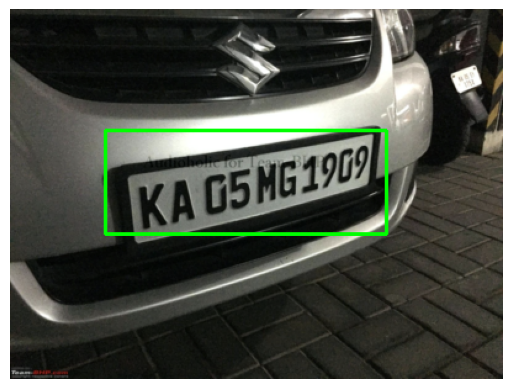

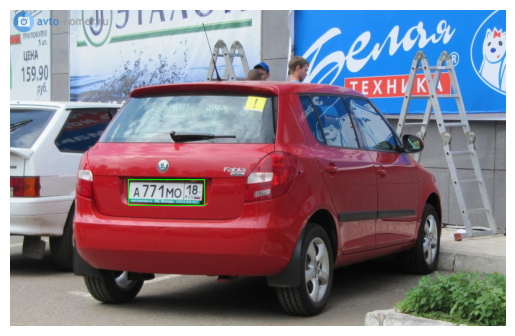

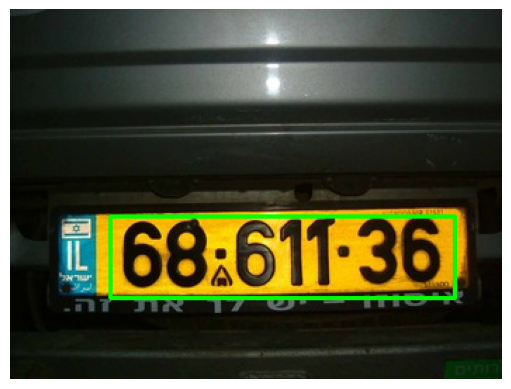

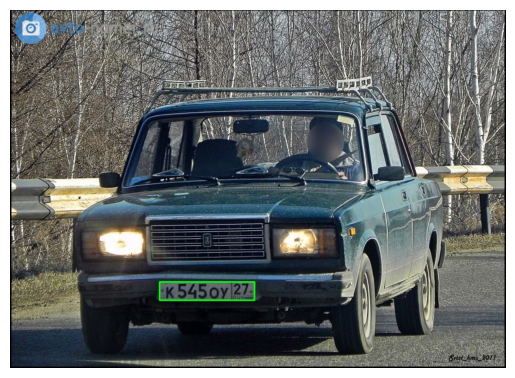

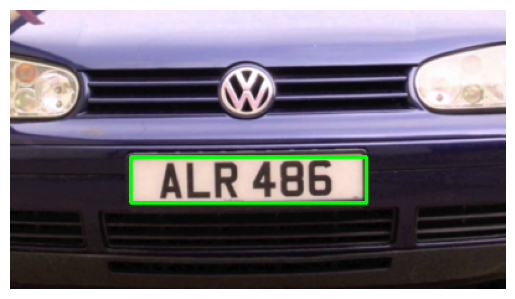

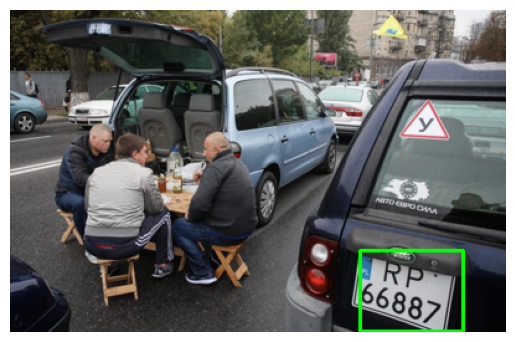

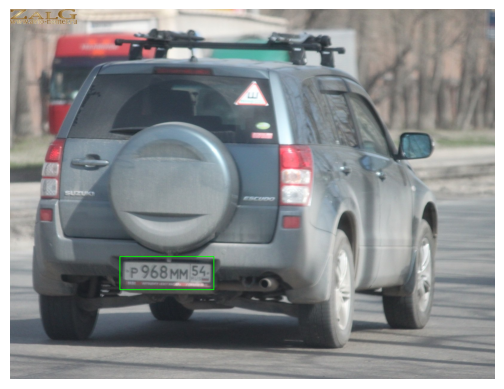

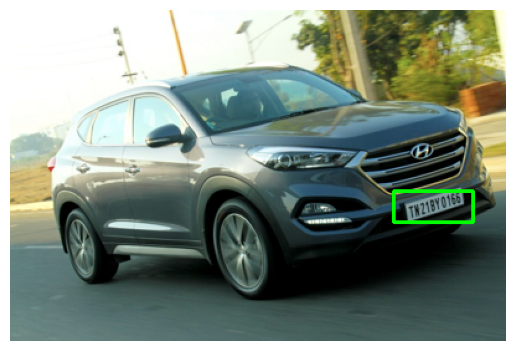

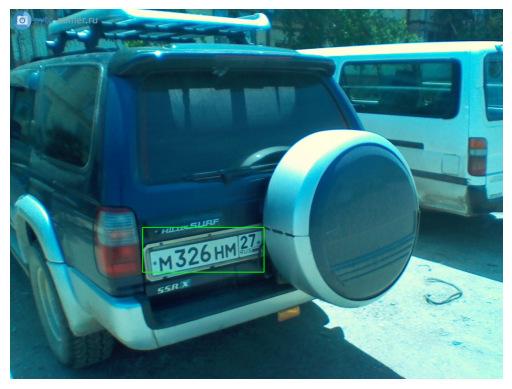

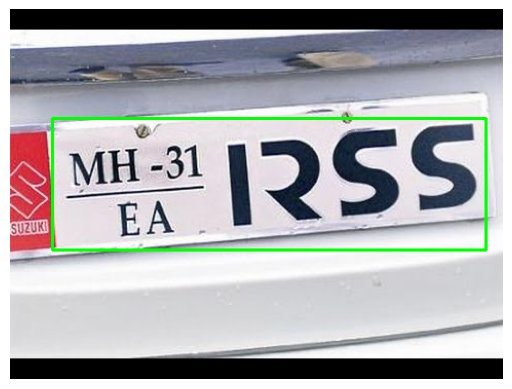

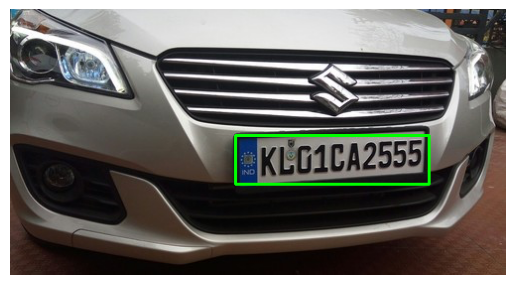

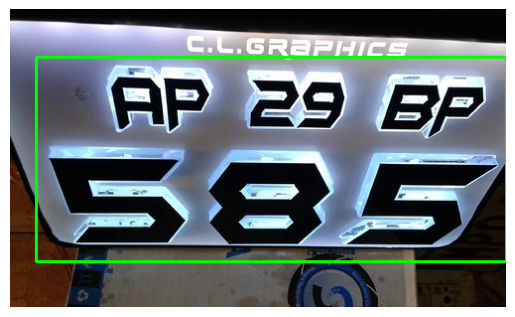

In [2]:
import os
import cv2 
import random
import matplotlib.pyplot as plt

random.seed(RANDOM_SEED)

train_files = os.listdir(IMG_DIR_TRAIN)
sample = random.sample(train_files, 12)

for img in sample:
    img_path = os.path.join(IMG_DIR_TRAIN, img)
    label_path = os.path.join(LABEL_DIR_TRAIN, os.path.join(os.path.splitext(img)[0])+ ".txt")
    img = cv2.imread(img_path)
    
    h, w, _ = img.shape
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.strip().split())
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()


    
    

In [3]:
import torch

print(torch.cuda.is_available())

True


In [4]:
!yolo detect train data=data.yaml model=yolo26n.pt epochs=50 name='car_number_1105_ep50'


New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.38  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650 with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0

In [ ]:
# метрики на тестовом датасете (который использовала модель)

from ultralytics import YOLO

model = YOLO("runs/detect/car_number_1105_ep50/weights/best.pt")

metrics = model.val(
    data = "data.yaml",
    split = "test",
    imgsz = 960
)

print("mAP@0.5 =", metrics.box.map50)
print("mAP@0.5:0.95 =", metrics.box.map)
print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)

Ultralytics 8.4.38  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650 with Max-Q Design, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 150.557.9 MB/s, size: 233.2 KB)
val: Scanning C:\Users\alina\Desktop\cv_labs\lab1_cv\dataset\labels\test... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 99.9it/s 0.1s3s
val: New cache created: C:\Users\alina\Desktop\cv_labs\lab1_cv\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 31.4s/it 31.4s
                   all         14         17      0.902      0.824      0.879      0.368
Speed: 18.8ms preprocess, 130.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\alina\Desktop\cv_labs\lab1_cv\runs\detect\val
mAP@0.5 = 0.8794230769230771
mAP@0.5:0.95 = 0.36837642787072006
Precision = 0.9022987618308702
Recall = 0.823


0: 384x640 (no detections), 139.5ms
Speed: 12.8ms preprocess, 139.5ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)


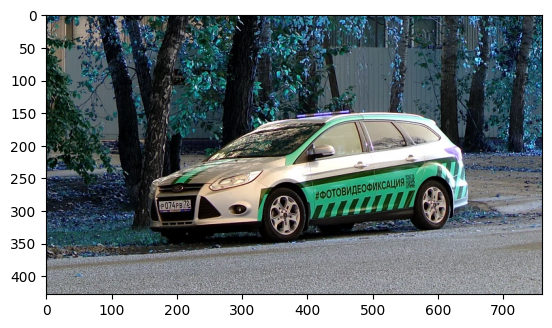

In [ ]:
import requests
from PIL import Image
from io import BytesIO

url_image_1 = "https://vsluh.ru/upload/resize_cache/archive/novosti/transport/5ae/mobilnye-kamery-na-tyumenskikh-dorogakh-kak-eto-budet-rabotat_399449/images/760_760_0/csj8kc7khitly51ib0669b7ct1yg03qv.jpg"
response = requests.get(url_image_1)
img = Image.open(BytesIO(response.content))
results = model.predict(
    img
)
result = results[0].plot()
plt.imshow(result)
plt.show()



0: 480x640 1 license_plate, 67.5ms
Speed: 488.7ms preprocess, 67.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


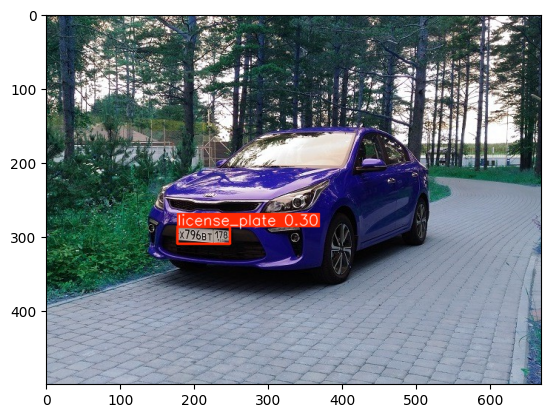

In [14]:
img2_path = "https://www.autostat.ru/application/includes/blocks/big_photo/images/cache/000/046/251/b7886bd8-670-0.jpg?_=1501573196"
response = requests.get(img2_path)
img = Image.open(BytesIO(response.content))
results = model.predict(img)
result = results[0].plot()
plt.imshow(result)


чем более перпендикулярна плоскость номера к плоскости камеры - тем хуже считывается номер